# Amazon Sales Analysis Project

## Step 1: Load Dataset
We start by importing the dataset `amazon.csv` using Pandas.  
This gives us the first look at product details such as prices, ratings, and reviews

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("data/amazon.csv")

# Quick look
print(df.head())
print(df.info())
print(df.describe())


   product_id                                       product_name  \
0  B07JW9H4J1  Wayona Nylon Braided USB to Lightning Fast Cha...   
1  B098NS6PVG  Ambrane Unbreakable 60W / 3A Fast Charging 1.5...   
2  B096MSW6CT  Sounce Fast Phone Charging Cable & Data Sync U...   
3  B08HDJ86NZ  boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...   
4  B08CF3B7N1  Portronics Konnect L 1.2M Fast Charging 3A 8 P...   

                                            category discounted_price  \
0  Computers&Accessories|Accessories&Peripherals|...             ₹399   
1  Computers&Accessories|Accessories&Peripherals|...             ₹199   
2  Computers&Accessories|Accessories&Peripherals|...             ₹199   
3  Computers&Accessories|Accessories&Peripherals|...             ₹329   
4  Computers&Accessories|Accessories&Peripherals|...             ₹154   

  actual_price discount_percentage rating rating_count  \
0       ₹1,099                 64%    4.2       24,269   
1         ₹349                 43%  

## Step 2: Clean Ratings
The `rating` column was stored as text.  
We convert it into numeric values so we can calculate averages and visualize ratings by category.

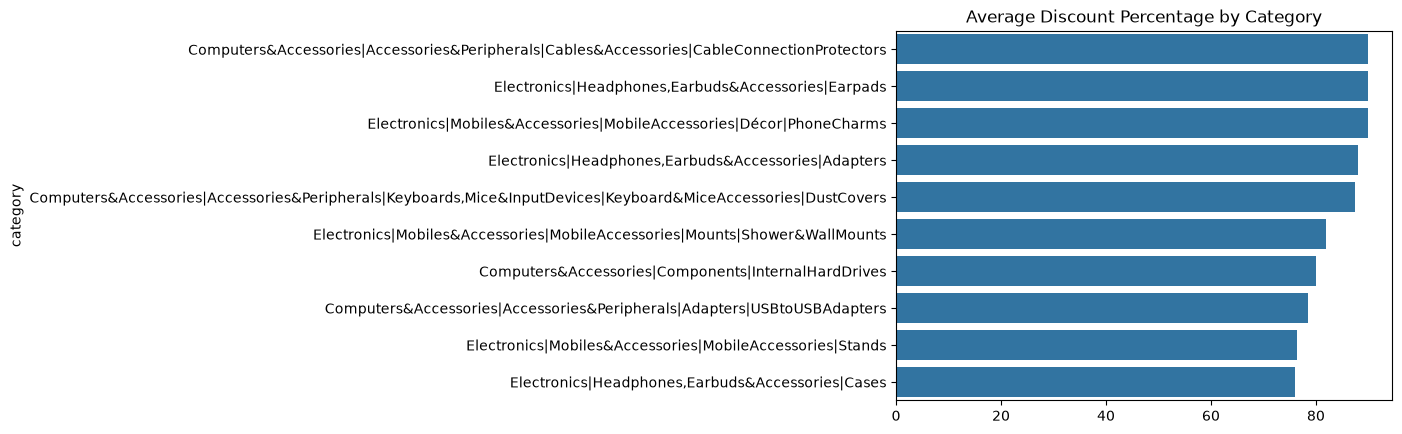

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("data/amazon.csv")

# Clean price columns
df['discounted_price'] = df['discounted_price'].str.replace('₹','').str.replace(',','').astype(float)
df['actual_price'] = df['actual_price'].str.replace('₹','').str.replace(',','').astype(float)
df['discount_percentage'] = df['discount_percentage'].str.replace('%','').astype(float)



## Step 3: Top Products by Rating Count
We group products by their name and count the number of ratings.  
This helps us identify the **most popular products** based on customer engagement.  
The bar chart below shows the top 10 products with the highest number of ratings.

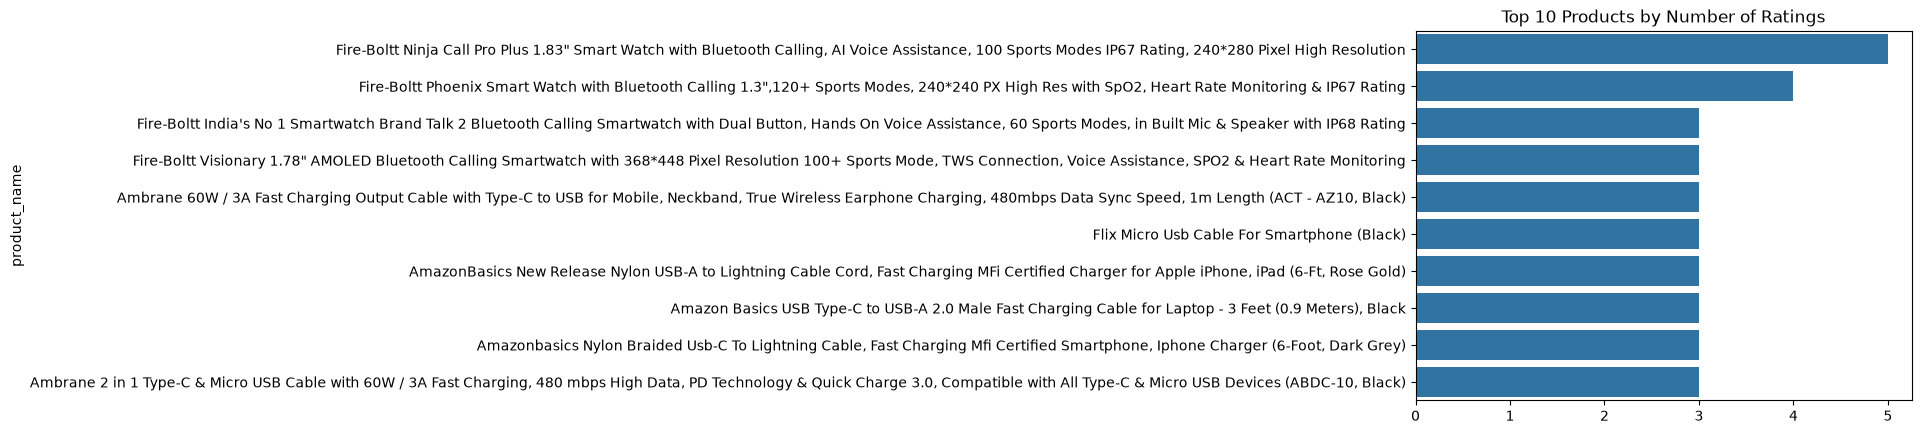

In [18]:
# Top 10 products by rating count
top_products = df.groupby('product_name')['rating_count'].count().sort_values(ascending=False).head(10)
sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Top 10 Products by Number of Ratings")
plt.show()

## Step 4: Average Discount by Category
We calculate the average discount percentage for each product category.  
This analysis highlights which categories offer the **biggest savings** to customers.  
The bar chart below shows the top 10 categories with the highest average discounts.

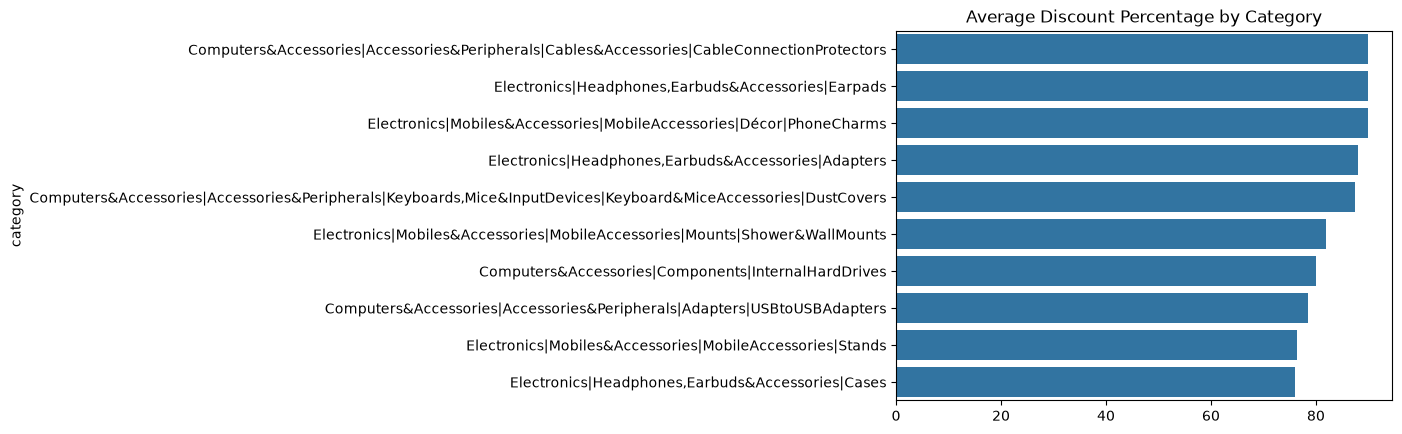

In [19]:
# Average discount by category
category_discount = df.groupby('category')['discount_percentage'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=category_discount.values, y=category_discount.index)
plt.title("Average Discount Percentage by Category")
plt.show()

## Step 5: Distribution of Discount Amounts
We calculate the discount amount for each product by subtracting the discounted price from the actual price.  
This shows how much money customers save on each item.  

The histogram below visualizes the distribution of discount amounts across all products.  
It helps us understand whether most discounts are small, moderate, or very large.



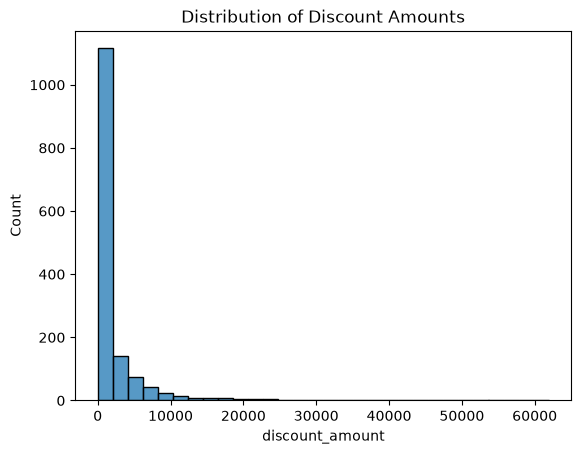

In [3]:
df['discount_amount'] = df['actual_price'] - df['discounted_price']
sns.histplot(df['discount_amount'], bins=30)
plt.title("Distribution of Discount Amounts")
plt.show()


## Step 6: Top Categories by Average Rating
We convert the `rating` column into numeric values so that we can calculate averages.  
Next, we group products by their category and compute the average rating for each.  

This analysis helps us identify which categories are most highly rated by customers.  
The bar chart below shows the top 10 categories with the highest average ratings.


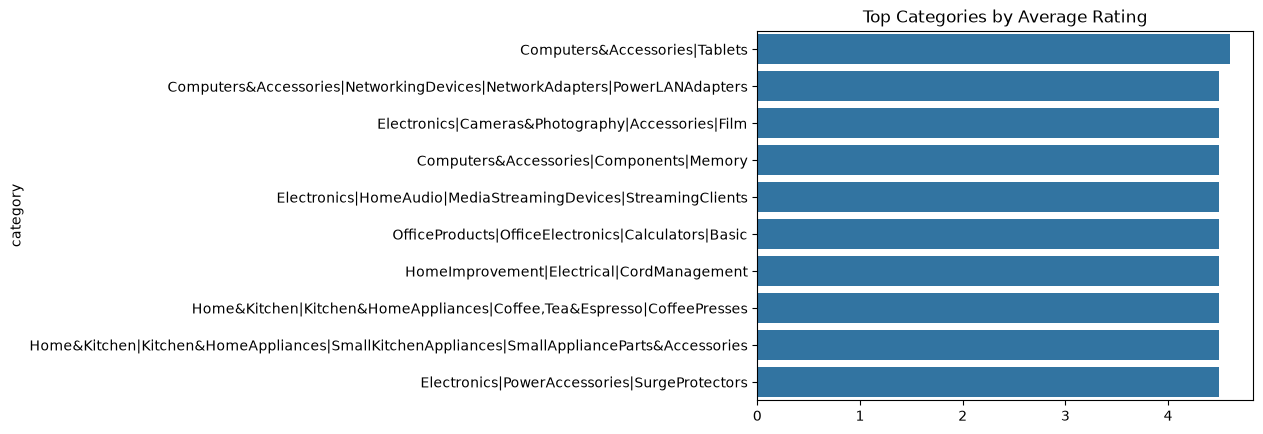

In [5]:
# Convert rating to numeric
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# Now group by category and calculate average rating
category_rating = df.groupby('category')['rating'].mean().sort_values(ascending=False).head(10)

# Plot
sns.barplot(x=category_rating.values, y=category_rating.index)
plt.title("Top Categories by Average Rating")
plt.show()



## Step 7: Top Products by Popularity
We clean the `rating_count` column by removing commas and converting it into numeric values.  
This allows us to sort products based on the number of ratings they have received.  

By sorting in descending order, we identify the **top 10 most popular products**.  
The table below shows these products along with their rating counts and average ratings.


In [7]:
# Clean rating_count column
df['rating_count'] = df['rating_count'].str.replace(',','').astype(float)

# Now you can sort by rating_count
top_popular = df.sort_values('rating_count', ascending=False).head(10)
print(top_popular[['product_name','rating_count','rating']])


                                          product_name  rating_count  rating
47   Amazon Basics High-Speed HDMI Cable, 6 Feet - ...      426973.0     4.4
65   Amazon Basics High-Speed HDMI Cable, 6 Feet (2...      426973.0     4.4
12   AmazonBasics Flexible Premium HDMI Cable (Blac...      426973.0     4.4
684  AmazonBasics Flexible Premium HDMI Cable (Blac...      426972.0     4.4
400  boAt Bassheads 100 in Ear Wired Earphones with...      363713.0     4.1
352  boAt Bassheads 100 in Ear Wired Earphones with...      363713.0     4.1
584  boAt BassHeads 100 in-Ear Wired Headphones wit...      363711.0     4.1
371  Redmi 9A Sport (Coral Green, 2GB RAM, 32GB Sto...      313836.0     4.1
370  Redmi 9 Activ (Carbon Black, 4GB RAM, 64GB Sto...      313836.0     4.1
566  Redmi 9A Sport (Coral Green, 3GB RAM, 32GB Sto...      313832.0     4.1


# Insights & Conclusion

Through this Amazon Sales Analysis, we discovered several key patterns:

- 📊 **Popular Products**: Items with the highest rating counts are not always the ones with the highest ratings, showing that popularity and quality can differ.
- ⭐ **Top Categories by Rating**: Certain categories consistently achieve higher average ratings, reflecting strong customer satisfaction and brand trust.
- 💰 **Discount Trends**: Categories like Mobile Accessories and Smart Watches offer the largest discounts, making them attractive for deal‑seeking customers.
- 🔄 **Discount vs Rating**: Higher discounts do not always lead to better ratings — product quality and customer experience matter more than price cuts.
- 🛒 **Customer Behavior**: Products with more reviews tend to have slightly higher ratings, suggesting that popularity builds credibility.

## Final Note
This project demonstrates skills in:
- Data cleaning (handling text, symbols, and missing values)
- Exploratory Data Analysis (EDA) with Pandas
- Visualization using Matplotlib and Seaborn
- Extracting actionable business insights from raw data

The analysis highlights how pricing strategies, discounts, and customer reviews interact — valuable knowledge for e‑commerce and retail analytics.
